This notebook gives the plotting script for Figs. 10 and 11 in the manuscript. The required csv files are provided

/var/folders/hg/3b70bvrd69gcgxnf6h4lx8c00000gn/T/ipykernel_65864/4035846779.py:150: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


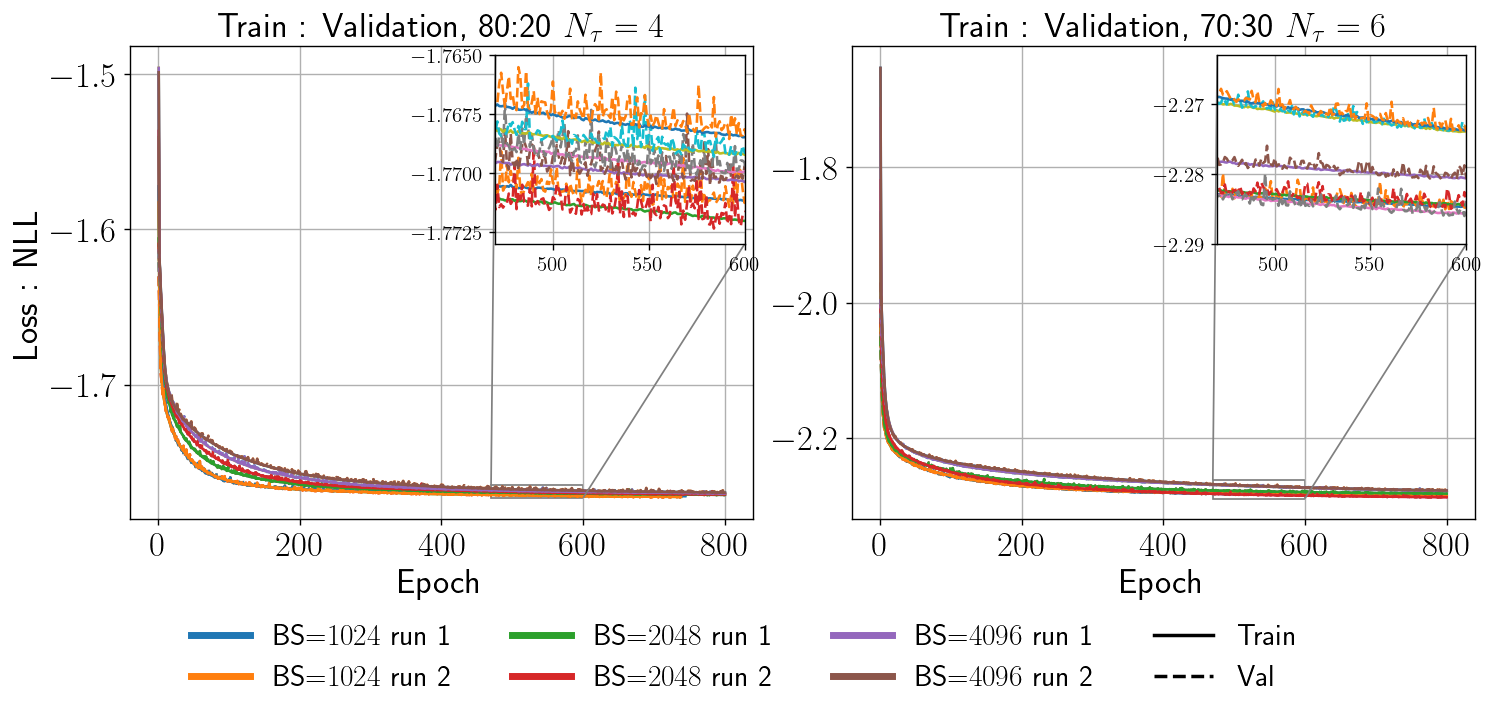

In [ ]:
#Produces Fig.10
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from matplotlib.lines import Line2D

plt.rcParams["text.usetex"] = True 

# !!IMPORTANT!! Define file paths and labels for both Nt4 and Nt6
files_and_labelsNt4 = [
    ("/path/to/Nt4/loss_ep800_bs1024_nummade8_loop1.csv", r"BS=$1024$ run 1"),
    ("/path/to/Nt4/loss_ep800_bs1024_nummade8_loop2.csv", r"BS=$1024$ run 2"),
    ("/path/to/Nt4/loss_ep800_bs2048_nummade8_loop1.csv", r"BS=$2048$ run 1"),
    ("/path/to/Nt4/loss_ep800_bs2048_nummade8_loop2.csv", r"BS=$2048$ run 2"),
    ("/path/to/Nt4/loss_ep800_bs4096_nummade8_loop1.csv", r"BS=$4096$ run 1"),
    ("/path/to/Nt4/loss_ep800_bs4096_nummade8_loop2.csv", r"BS=$4096$ run 2"),
]

files_and_labelsNt6 = [
    ("path/to/Nt6/loss_ep800_bs1024_nummade8_loop1.csv", r"BS=$1024$ run 1"),
    ("path/to/Nt6/loss_ep800_bs1024_nummade8_loop3.csv", r"BS=$1024$ run 2"),
    ("path/to/Nt6/loss_ep800_bs2048_nummade8_loop1.csv", r"BS=$2048$ run 1"),
    ("path/to/Nt6/loss_ep800_bs2048_nummade8_loop3.csv", r"BS=$2048$ run 2"),
    ("path/to/Nt6/loss_ep800_bs4096_nummade8_loop1.csv", r"BS=$4096$ run 1"),
    ("path/to/Nt6/loss_ep800_bs4096_nummade8_loop3.csv", r"BS=$4096$ run 2"),
]

def load_series(files_and_labels):
    out = []
    for filename, label in files_and_labels:
        df = pd.read_csv(filename, header=None, usecols=[0, 1, 2])
        df.columns = ["epoch", "loss", "val_loss"]
        df = df.apply(pd.to_numeric, errors="coerce").dropna()
        out.append((df, label))
    return out

dataNt4 = load_series(files_and_labelsNt4)
dataNt6 = load_series(files_and_labelsNt6)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=125)
ax4, ax6 = axes

# ---- Nt4 subplot ----
for df4, label in dataNt4:
    ax4.plot(df4["epoch"], df4["loss"], label=f"Train {label}")
    ax4.plot(df4["epoch"], df4["val_loss"], label=f"Val {label}", linestyle="--")

ax4.set_xlabel(r"Epoch", fontsize=20)
ax4.set_ylabel(r"Loss : NLL", fontsize=20)
ax4.set_title(r"Train : Validation, 80:20  $N_{\tau}=4$",fontsize=20)
ax4.grid(True)
ax4.tick_params(axis="x", labelsize=20)
ax4.tick_params(axis="y", labelsize=20)

# inset for Nt4
axins4 = inset_axes(ax4, width="40%", height="40%", loc="upper right")
for df4, _ in dataNt4:
    axins4.plot(df4["epoch"], df4["loss"])
    axins4.plot(df4["epoch"], df4["val_loss"], linestyle="--")

axins4.set_xlim(470, 600)

subset_vals4 = []
for df4, _ in dataNt4:
    subset = df4[(df4["epoch"] >= 470) & (df4["epoch"] <= 600)]
    subset_vals4.append(subset[["loss", "val_loss"]].to_numpy().ravel())

subset_vals4 = np.concatenate(subset_vals4)
axins4.set_ylim(-1.773, -1.765)

axins4.grid(True)
mark_inset(ax4, axins4, loc1=2, loc2=4, fc="none", ec="0.5")
axins4.tick_params(axis="x", labelsize=12)
axins4.tick_params(axis="y", labelsize=12)

# ---- Nt6 subplot ----
for df6, label in dataNt6:
    ax6.plot(df6["epoch"], df6["loss"], label=f"Train {label}")
    ax6.plot(df6["epoch"], df6["val_loss"], label=f"Val {label}", linestyle="--")

ax6.set_xlabel(r"Epoch", fontsize=20)
ax6.set_title(r"Train : Validation, 70:30  $N_{\tau}=6$",fontsize=20)
ax6.grid(True)
ax6.tick_params(axis="x", labelsize=20)
ax6.tick_params(axis="y", labelsize=20)

axins6 = inset_axes(ax6, width="40%", height="40%", loc="upper right")
for df6, _ in dataNt6:
    axins6.plot(df6["epoch"], df6["loss"])
    axins6.plot(df6["epoch"], df6["val_loss"], linestyle="--")

axins6.set_xlim(470, 600)

subset_vals6 = []
for df6, _ in dataNt6:
    subset = df6[(df6["epoch"] >= 470) & (df6["epoch"] <= 600)]
    subset_vals6.append(subset[["loss", "val_loss"]].to_numpy().ravel())

subset_vals6 = np.concatenate(subset_vals6)
axins6.set_ylim(-2.29, -2.263)
axins6.tick_params(axis="x", labelsize=12)
axins6.tick_params(axis="y", labelsize=12)

axins6.grid(True)
mark_inset(ax6, axins6, loc1=2, loc2=4, fc="none", ec="0.5")

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
run_labels = [label for _, label in files_and_labelsNt4]  # assumes same ordering as Nt6
run_colors = {label: colors[i % len(colors)] for i, label in enumerate(run_labels)}

# --- Nt4 subplot ---
for df4, label in dataNt4:
    c = run_colors[label]
    ax4.plot(df4["epoch"], df4["loss"], color=c, label="_nolegend_")
    ax4.plot(df4["epoch"], df4["val_loss"], color=c, linestyle="--", label="_nolegend_")

# --- Nt6 subplot ---
for df6, label in dataNt6:
    c = run_colors[label]
    ax6.plot(df6["epoch"], df6["loss"], color=c, label="_nolegend_")
    ax6.plot(df6["epoch"], df6["val_loss"], color=c, linestyle="--", label="_nolegend_")


run_handles = [
    Line2D([0], [0], color=run_colors[label], lw=4, label=label)
    for label in run_labels
]

style_handles = [
    Line2D([0], [0], color="black", lw=2, linestyle="-",  label="Train"),
    Line2D([0], [0], color="black", lw=2, linestyle="--", label="Val"),
]

all_handles = run_handles + style_handles

leg = fig.legend(
    handles=all_handles,
    loc="lower center",
    ncol=4,                      
    frameon=False,
    bbox_to_anchor=(0.5, -0.16),
    fontsize=17
)

fig.subplots_adjust(bottom=0.22)
#plt.savefig('run_Loss_Nt4Nt6_2runs.pdf',bbox_inches="tight",
#    pad_inches=0.02,
#    bbox_extra_artists=(leg,))

fig.tight_layout()
plt.show()


In [ ]:
#Produces Fig.11
import re
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
plt.rcParams["text.usetex"] = True

files_and_labels = [
    #("./loss_ep800_bs1024_nummade8_loop1.csv", r"BS=$1024$ run 1"),
    #("./loss_ep800_bs1024_nummade8_loop2.csv", r"BS=$1024$ run 2"),
    #("./loss_ep800_bs1024_nummade8_loop3.csv", r"BS=$1024$ run 3"),
    #("./loss_ep800_bs1024_nummade8_loop4.csv", r"BS=$1024$ run 4"),
    #("./loss_ep800_bs1024_nummade8_loop5.csv", r"BS=$1024$ run 5"),
    ("./loss_ep800_bs2048_nummade8_loop1.csv", r"BS=$2048$ run 1"),
    ("./loss_ep800_bs2048_nummade8_loop2.csv", r"BS=$2048$ run 2"),
    ("./loss_ep800_bs2048_nummade8_loop3.csv", r"BS=$2048$ run 3"),
    ("./loss_ep800_bs2048_nummade8_loop4.csv", r"BS=$2048$ run 4"),
    ("./loss_ep800_bs2048_nummade8_loop5.csv", r"BS=$2048$ run 5"),
    #("./loss_ep800_bs4096_nummade8_loop1.csv", r"BS=$4096$ run 1"),
    #("./loss_ep800_bs4096_nummade8_loop2.csv", r"BS=$4096$ run 2"),
    #("./loss_ep800_bs4096_nummade8_loop3.csv", r"BS=$4096$ run 3"),
    #("./loss_ep800_bs4096_nummade8_loop4.csv", r"BS=$4096$ run 4"),
    #("./loss_ep800_bs4096_nummade8_loop5.csv", r"BS=$4096$ run 5"),
]

def extract_run(filename: str) -> int:
    m = re.search(r"loop(\d+)", filename)
    return int(m.group(1)) if m else 0

# --- keep only BS=2048 and sort by run ---
bs2048 = [(fn, lab) for fn, lab in files_and_labels if "bs2048" in fn]
bs2048 = sorted(bs2048, key=lambda x: extract_run(x[0]))

# --- load data ---
runs = []
for filename, label in bs2048:
    df = pd.read_csv(filename, header=None, usecols=[0, 1, 2])
    df.columns = ["epoch", "loss", "val_loss"]
    df = df.apply(pd.to_numeric, errors="coerce").dropna()
    run_id = extract_run(filename)
    runs.append((run_id, df))

# --- plot ---
fig, ax = plt.subplots(figsize=(6, 5),dpi=125)

colors = plt.cm.tab10.colors  # 10 distinct colors

run_handles = []
for i, (run_id, df) in enumerate(runs):
    color = colors[i % len(colors)]

    # Train (solid)
    ax.plot(
        df["epoch"], df["loss"],
        color=color, linestyle="-", linewidth=1.6, alpha=0.9
    )
    # Validation (dashed), same color
    ax.plot(
        df["epoch"], df["val_loss"],
        color=color, linestyle="--", linewidth=1.6, alpha=0.9
    )

    run_handles.append(Line2D([0], [0], color=color, lw=4, label=f"{run_id}"))

ax.set_xlabel("Epoch", fontsize=20)
ax.set_ylabel("Loss : NLL", fontsize=20)
ax.tick_params(axis="x", labelsize=20)
ax.tick_params(axis="y", labelsize=20)
#ax.set_title(r"BS=$2048$ (5 runs), Train vs Validation, $N_{\tau}=6$",fontsize=16)
ax.grid(True)

# -------- inset --------
axins = inset_axes(ax, width="42%", height="42%", loc="upper right")

for i, (run_id, df) in enumerate(runs):
    color = colors[i % len(colors)]
    axins.plot(df["epoch"], df["loss"], color=color, linestyle="-", linewidth=1.2)
    axins.plot(df["epoch"], df["val_loss"], color=color, linestyle="--", linewidth=1.2)

# Set your zoom window here
axins.set_xlim(470, 600)
axins.set_ylim(-2.287, -2.275)  # adjust as needed
axins.tick_params(axis="x", labelsize=12)
axins.tick_params(axis="y", labelsize=12)
axins.grid(True)
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")

# -------- legends outside --------
style_handles = [
    Line2D([0], [0], color="black", linestyle="-",  lw=2, label="Train"),
    Line2D([0], [0], color="black", linestyle="--", lw=2, label="Validation"),
]

# Reserve space at bottom for legends
fig.subplots_adjust(bottom=0.28)

# Runs legend (outside, bottom center)
leg= fig.legend(
    handles=run_handles,
    loc="lower center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, -0.08),
    fontsize=16
)

# Style legend (outside, bottom center, below runs)
fig.legend(
    handles=style_handles,
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 0.03),
    fontsize=16
)
#plt.savefig('run_Loss_2048Nt6_5runs.pdf',bbox_inches="tight",
#    pad_inches=0.02,
#    bbox_extra_artists=(leg,))
plt.show()
